In [1]:
!pip install ultralytics roboflow
import ultralytics
ultralytics.checks()

Ultralytics 8.4.50 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Setup complete ✅ (4 CPUs, 31.4 GB RAM, 6842.1/8062.4 GB disk)


In [2]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="DUDS52pDMAJ96Sq9eX58")
project = rf.workspace("light-wln2h").project("person-worker-gzvcf")
version = project.version(1)
dataset = version.download("yolov8-obb")
                

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to person-worker-1 in yolov8-obb:: 100%|██████████| 3587/3587 [00:00<00:00, 5559.71it/s]


In [7]:
import yaml

yaml_file = f"{dataset.location}/data.yaml"
with open(yaml_file, 'r') as f:
    data = yaml.safe_load(f)

# Force the validation path to be the same as the train path so it doesn't crash
data['val'] = data['train']

with open(yaml_file, 'w') as f:
    yaml.dump(data, f)

print("Fixed data.yaml successfully!")

Fixed data.yaml successfully!


In [8]:
!yolo task=segment mode=train data={dataset.location}/data.yaml model=yolov8n-seg.pt epochs=10 imgsz=640 batch=16

Ultralytics 8.4.50 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/person-worker-1/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n-seg.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train-2, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=T

In [9]:
!wget https://images.unsplash.com/photo-1504307651254-35680f356dfd -O test.jpg

--2026-05-13 16:32:04--  https://images.unsplash.com/photo-1504307651254-35680f356dfd
Resolving images.unsplash.com (images.unsplash.com)... 151.101.194.208, 151.101.2.208, 151.101.130.208, ...
Connecting to images.unsplash.com (images.unsplash.com)|151.101.194.208|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 3752890 (3.6M) [image/jpeg]
Saving to: ‘test.jpg’

test.jpg            100%[===================>]   3.58M  11.3MB/s    in 0.3s    

2026-05-13 16:32:05 (11.3 MB/s) - ‘test.jpg’ saved [3752890/3752890]



Ultralytics 8.4.50 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLOv8n-seg summary (fused): 86 layers, 3,258,259 parameters, 0 gradients, 11.3 GFLOPs

image 1/1 /kaggle/working/test.jpg: 448x640 4 0s, 57.3ms
Speed: 4.7ms preprocess, 57.3ms inference, 46.7ms postprocess per image at shape (1, 3, 448, 640)
Results saved to /kaggle/working/runs/segment/predict
💡 Learn more at https://docs.ultralytics.com/modes/predict


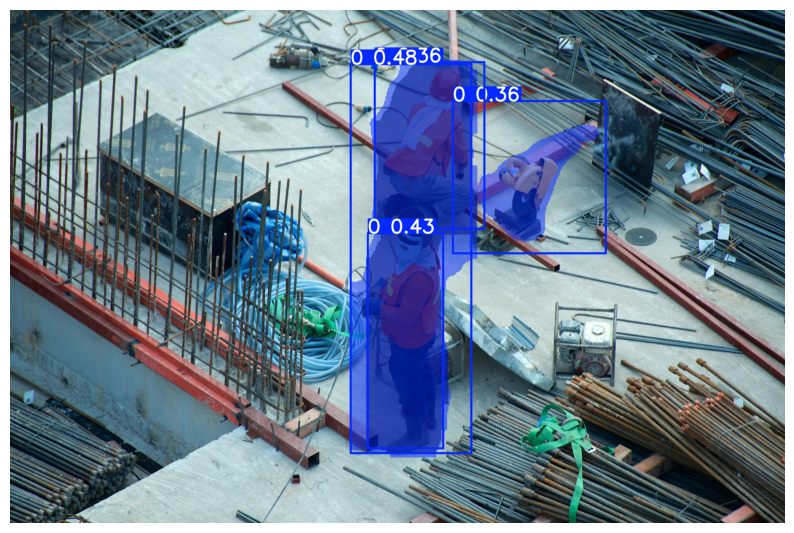

In [10]:
# Run your trained model on the new test image
!yolo task=segment mode=predict model=/kaggle/working/runs/segment/train-2/weights/best.pt source='test.jpg' save=True

import cv2
import matplotlib.pyplot as plt
import glob

# YOLO auto-creates folders like predict, predict2, etc. This finds the newest one automatically.
try:
    latest_predict_dir = max(glob.glob('/kaggle/working/runs/segment/predict*'))
    img_path = f"{latest_predict_dir}/test.jpg"

    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(10, 10))
    plt.imshow(img)
    plt.axis('off')
    plt.show()
    
except Exception as e:
    print("Wait for the prediction to finish first!", e)